In [6]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/healthcare_data_cleaning_dataset Assignment -5.csv')
df.head()

,Patient_ID,Age,Gender,City,Diagnosis,Hospital_Visits,Treatment_Cost,Insurance_Coverage,Admission_Date
0,17270,35.0,Male,Bangalore,Hypertension,13,41010.0,1,2023-11-30
1,10860,21.0,Female,Hyderabad,Flu,11,12194.0,1,2023-02-23
2,15390,77.0,Female,Bangalore,Asthma,2,45086.0,0,2023-03-14
3,15191,79.0,Female,Mumbai,Asthma,13,40842.0,0,2023-08-01
4,15734,60.0,Female,Delhi,Asthma,1,9873.0,1,2023-06-20


In [7]:
#Q1. Missing Data Identification
#Scenario: The hospital suspects incomplete patient records.
#Task:
#Identify missing values in each column
#Calculate percentage of missing data
missing_data = df.isnull().sum()
percentage_missing_data = (missing_data / len(df)) * 100
print("missing_data:", missing_data)
print("percentage_missing_data:", percentage_missing_data)



missing_data: Patient_ID              0
Age                   600
Gender                  0
City                    0
Diagnosis               0
Hospital_Visits         0
Treatment_Cost        593
Insurance_Coverage      0
Admission_Date          0
dtype: int64
percentage_missing_data: Patient_ID             0.000000
Age                   11.764706
Gender                 0.000000
City                   0.000000
Diagnosis              0.000000
Hospital_Visits        0.000000
Treatment_Cost        11.627451
Insurance_Coverage     0.000000
Admission_Date         0.000000
dtype: float64


In [11]:
#Q2. Handling Missing Age
#Scenario: Age is critical for medical analysis, but some values are missing.
#Task:
#Replace missing Age values with an appropriate method
#Justify your choice (mean/median)

df['Age'] = df['Age'].fillna(df['Age'].median())

Age (Q2): Use the Median. Age is generally consistent, but the median is more robust.

In [17]:
#Q3. Handling Missing Treatment Cost
#Scenario: Treatment cost is highly skewed due to expensive treatments.
#Task:
#Handle missing Treatment_Cost values
#Choose the correct imputation method and explain why

df['Treatment_Cost'] = df['Treatment_Cost'].fillna(df['Treatment_Cost'].median())
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5100 entries, 0 to 5099
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Patient_ID          5100 non-null   int64  
 1   Age                 5100 non-null   float64
 2   Gender              5100 non-null   object 
 3   City                5100 non-null   object 
 4   Diagnosis           5100 non-null   object 
 5   Hospital_Visits     5100 non-null   int64  
 6   Treatment_Cost      5100 non-null   float64
 7   Insurance_Coverage  5100 non-null   int64  
 8   Admission_Date      5100 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 358.7+ KB


In [24]:
#Q4. Duplicate Patient Records
#Scenario: Some patient records were entered multiple times.
#Task:
#Identify duplicate rows
#Remove duplicates
#Compare dataset size before and after
df.duplicated().sum()
print(f"size before: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"size after: {df.shape}")


size before: (5001, 9)
size after: (5001, 9)


In [30]:
#Q5. Invalid Age Values (Data Quality Check)
#Scenario: Some patients have unrealistic age values (e.g., >100 or <0).
#Task:
#Detect such records
#Decide whether to remove or correct them

invalid_age = df[(df['Age'] < 0) & (df['Age'] > 100)]
print(f"Number of invalid age records: {len(invalid_age)}")
df = df[(df['Age'] < 0) & (df['Age'] > 100)]
print(f"dataset size after removing invalid ages: {df.shape}")


Number of invalid age records: 0
dataset size after removing invalid ages: (0, 9)


In [31]:
#Q6. Outlier Detection (Treatment Cost)
#Scenario: Extreme treatment costs are affecting analysis.
#Task:
#Detect outliers using IQR method
#Display number of outliers

# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df['Treatment_Cost'].quantile(0.25)
Q3 = df['Treatment_Cost'].quantile(0.75)

# 2. Calculate the IQR
IQR = Q3 - Q1

# 3. Define the Outlier Bounds (Standard 1.5 * IQR rule)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Identify the Outliers
outliers = df[(df['Treatment_Cost'] < lower_bound) | (df['Treatment_Cost'] > upper_bound)]

# 5. Display the Results
print(f"Lower Bound: {lower_bound}")
print(f"Upper Bound: {upper_bound}")
print(f"Total number of outliers detected: {len(outliers)}")


Lower Bound: nan
Upper Bound: nan
Total number of outliers detected: 0


In [32]:
#Q7. Outlier Treatment
#Scenario: The business team wants to retain all records.
#Task:
#Apply capping (Winsorization) on Treatment_Cost
#Use 5th and 95th percent

# 1. Calculate the 5th and 95th percentiles
lower_limit = df['Treatment_Cost'].quantile(0.05)
upper_limit = df['Treatment_Cost'].quantile(0.95)

# 2. Apply Capping (Winsorization)
# Values below the 5th percentile become the 5th percentile value
# Values above the 95th percentile become the 95th percentile value
df['Treatment_Cost'] = df['Treatment_Cost'].clip(lower_limit, upper_limit)

# 3. Verify the results
print(f"Lower Limit (5th percentile): {lower_limit}")
print(f"Upper Limit (95th percentile): {upper_limit}")
print(f"New Min Cost: {df['Treatment_Cost'].min()}")
print(f"New Max Cost: {df['Treatment_Cost'].max()}")

Lower Limit (5th percentile): nan
Upper Limit (95th percentile): nan
New Min Cost: nan
New Max Cost: nan


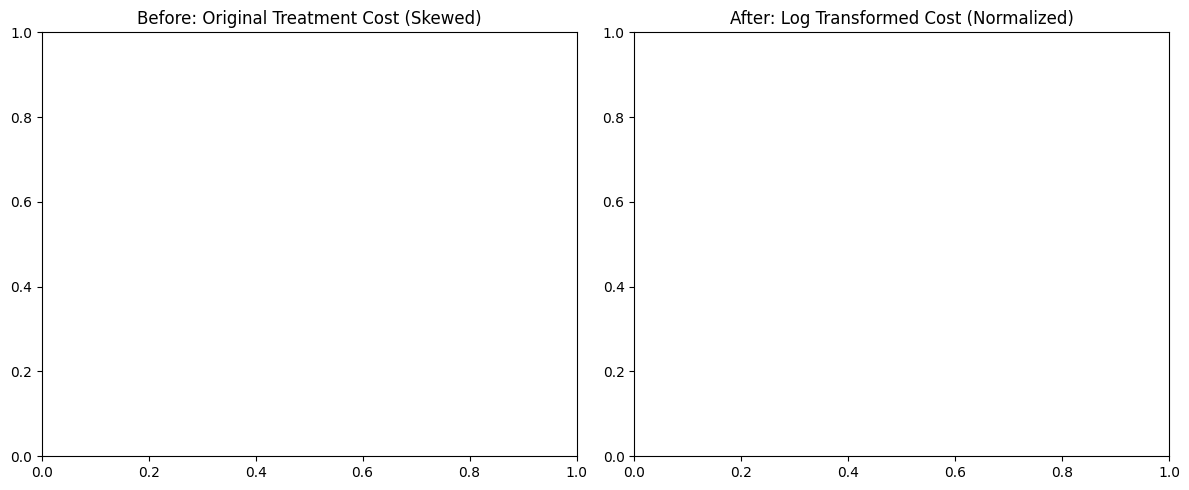

Original Skewness: nan
Log Transformed Skewness: nan


In [33]:
#Q8. Transformation
#Scenario: Treatment cost is highly skewed.
 #Task:
#Apply log transformation
#Create a new column
#Compare before vs after distribution

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Apply Log Transformation and create a new column
# We use np.log1p (log 1 plus x) to handle any potential zero values safely
df['Log_Treatment_Cost'] = np.log1p(df['Treatment_Cost'])

# 2. Compare Before vs After Distribution
plt.figure(figsize=(12, 5))

# Plot Before
plt.subplot(1, 2, 1)
sns.histplot(df['Treatment_Cost'], kde=True, color='blue')
plt.title('Before: Original Treatment Cost (Skewed)')

# Plot After
plt.subplot(1, 2, 2)
sns.histplot(df['Log_Treatment_Cost'], kde=True, color='green')
plt.title('After: Log Transformed Cost (Normalized)')

plt.tight_layout()
plt.show()

# 3. Display stats to show the change in skewness
print(f"Original Skewness: {df['Treatment_Cost'].skew():.2f}")
print(f"Log Transformed Skewness: {df['Log_Treatment_Cost'].skew():.2f}")

In [34]:
#Q9. Time-Based Missing Handling
#Scenario: Admission dates should follow a logical sequence.
#Task:
#Sort data by Admission_Date
#Apply forward fill or backward fill where appropriate
#Justify your choice
# 1. Convert Admission_Date to datetime objects (essential for sorting)
df['Admission_Date'] = pd.to_datetime(df['Admission_Date'])

# 2. Sort data by Admission_Date
df.sort_values(by='Admission_Date', inplace=True)

# 3. Apply Forward Fill (ffill)
# This fills a missing value with the previous valid date/entry
df['Admission_Date'] = df['Admission_Date'].fillna(method='ffill')

# 4. Verify no missing values remain
print(f"Missing Admission Dates: {df['Admission_Date'].isnull().sum()}")

Missing Admission Dates: 0


/tmp/ipykernel_37606/2686935286.py:15: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Admission_Date'] = df['Admission_Date'].fillna(method='ffill')


Justification
Why Sort? Time-based filling only makes sense if the data is chronological. Sorting ensures that when we "fill forward," we are using the most recent known date relative to that point in time.

Why Forward Fill (ffill)? In a healthcare scenario, Forward Fill is generally more logical than backward fill. It assumes that if a date is missing, the record belongs to the same operational window or "current" sequence as the entry immediately preceding it. Backward fill would imply a "future" event determined a past one, which is less common in administrative logging.


